# HMM-mixed MVO

Supervised HMM on the A001 train slice (2001-01-01 through 2014-01-03). Test (2014-01-06 to 2022-08-31) is used for a four-line regime plot and a non-overlapping mean-variance backtest.

This notebook is the A001 counterpart of `hmm-mixed-mvo-ew.ipynb`. Regime labels, HMM emissions, and specialist pools come from `HMM-Diffusion.ipynb` (`configs/default.yaml`). There is no validation slice.

Mixing is **row-append** by **overall synth share** of the MVO training matrix: `synth_rows / (real_rows + synth_rows)`. The real lookback stays 252 days × 10 assets. Extra synth days are chosen so that share is 0%, 10%, …, 90%. Markowitz stays on the original 10 assets.

- `0%`: `252 × 10` (real lookback only).
- `10%`: `280 × 10` (28 synth days).
- `20%`: `315 × 10` (63 synth days).
- `90%`: `2520 × 10` (2268 synth days).

- **hmm-diffusion**: synth days from the specialist pool for predicted regime `k*`. `k*` is the **window average argmax** of the open-loop daily labels on that hold.
- **mixed**: synth days from `trained_diffusion_withoutregime/generated_data.csv`.

On each hold the regime forecast uses the transition matrix only. Emissions on that hold are applied after scoring, and only on those 63 days.

Run scripts 01–04 first so regime labels and specialist pools exist. Markowitz is sum-to-1 with shorts allowed; no max-weight cap in the default sweep.


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

from hmmdiff.config import bootstrap_imports, config_path, load_config

cfg = load_config()
bootstrap_imports()

from hmmdiff import data, models, plots, pools, regimes
from hmmdiff.mvo import (
    load_specialist_pools,
    load_uncond_windows,
    run_mvo_backtest,
    run_scale_check,
    synth_rows_for_share,
    walk_open_loop,
)

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

HORIZON = 63
STEP = 63
LOOKBACK = 252
MIX_MODE = "row"
MIX_GRID = list(range(0, 91, 10))
RANDOM_STATE = 42
N_REGIMES = int(cfg["regimes"]["n_regimes"])
TOP_K = int(cfg["hmm"]["top_k"])
ASSET_COLS = list(cfg["data"]["asset_columns"])
UNCOND_CSV = REPO_ROOT / "trained_diffusion_withoutregime" / "generated_data.csv"

print(
    f"{N_REGIMES} regimes, lookback {LOOKBACK}, hold {HORIZON}, step {STEP}, "
    f"mix {MIX_MODE}, synth share {MIX_GRID[0]}..{MIX_GRID[-1]}%"
)

5 regimes, lookback 252, hold 63, step 63, mix row, synth share 0..90%


## Setup


In [2]:
returns = data.load_returns(cfg)
counts = data.split_counts(returns)
labels = regimes.load_labels(config_path(cfg, "regime_labels"))
regime_labels = labels.labels.astype(int)

train_data, test_data = data.build_model_frames(returns, regime_labels, cfg)
_, test_regimes = data.split_labels(returns, regime_labels)

test_dates = pd.to_datetime(returns.loc[data.test_mask(returns), "date"])
train_dates = pd.to_datetime(returns.loc[data.train_mask(returns), "date"])

log_panel = data.build_multivariate_log_returns(cfg)[ASSET_COLS]
simple_panel = np.expm1(log_panel)
simple_panel.index = pd.to_datetime(simple_panel.index)

pools_root = config_path(cfg, "pools")
if not pools.pools_available(pools_root, N_REGIMES):
    raise FileNotFoundError(
        f"Specialist pools not found under {pools_root}. Run scripts 03 and 04."
    )
specialist_pools = load_specialist_pools(pools_root, N_REGIMES)
uncond_windows = load_uncond_windows(UNCOND_CSV)

print(f"returns      {counts['n_returns']:>6}  {counts['start_date']} to {counts['end_date']}")
print(f"train        {counts['n_train']:>6}  {train_dates.iloc[0].date()} to {train_dates.iloc[-1].date()}")
print(f"test         {counts['n_test']:>6}  {test_dates.iloc[0].date()} to {test_dates.iloc[-1].date()}")
print(f"10-asset panel {len(simple_panel):>5}  {simple_panel.index[0].date()} to {simple_panel.index[-1].date()}")
print(f"uncond windows {uncond_windows.shape}")
print(f"specialist pools {[specialist_pools[k].shape for k in range(N_REGIMES)]}")

assert str(test_dates.iloc[0].date()) == "2014-01-06"
assert str(test_dates.iloc[-1].date()) == "2022-08-31"
assert counts["n_train"] == cfg["reference"]["n_train"]
assert counts["n_test"] == cfg["reference"]["n_test"]
assert len(test_regimes) == len(test_dates)


returns        9031  1988-01-20 to 2022-08-31
inner train    5079  1988-01-20 to 2007-07-09
validation     1694  2007-07-10 to 2014-01-03
10-asset panel  5653  2001-01-01 to 2022-08-31
uncond windows (1024, 128, 10)
specialist pools [(128, 128, 10), (128, 128, 10), (128, 128, 10), (128, 128, 10), (128, 128, 10)]


## Fit supervised HMM


In [3]:
init_dist = models.initial_distribution(train_data, N_REGIMES)
supervised = models.fit_supervised_hmm(train_data, N_REGIMES, cfg)

index = pd.Index(range(N_REGIMES), name="from")
columns = pd.Index(range(N_REGIMES), name="to")
print("Posterior transition matrix")
display(pd.DataFrame(supervised.transmat.round(3), index=index, columns=columns))
print("Emission parameters")
display(supervised.summary())
print("Initial distribution (inner-train frequencies)")
display(pd.Series(init_dist, index=range(N_REGIMES), name="pi0"))

sample: 100%|██████████| 300/300 [00:13<00:00, 21.79it/s, 31 steps of size 1.72e-01. acc. prob=0.84] 


Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9970,0.0020,0.0010,0.0000,0.0000
1,0.0010,0.9970,0.0010,0.0010,0.0000
2,0.0010,0.0020,0.9940,0.0020,0.0010
3,0.0000,0.0000,0.0110,0.9880,0.0000
4,0.0020,0.0010,0.0020,0.0120,0.9830


Emission parameters


,mean,sigma
regime,,
0,0.0087,0.5028
1,0.0202,0.6764
2,0.0043,0.9672
3,-0.0383,1.3822
4,-0.0355,1.9231


Initial distribution (inner-train frequencies)


0   0.2648
1   0.3227
2   0.2973
3   0.0965
4   0.0187
Name: pi0, dtype: float64

## Rolling open-loop forecast


In [4]:
walk = walk_open_loop(
    train_data.emission.values,
    test_data.emission.values,
    supervised.transmat,
    supervised.mu,
    supervised.sigma,
    init_dist,
    horizon=HORIZON,
    step=STEP,
)

print(f"holds {len(walk.hold_starts)}  first test day {test_dates.iloc[0].date()}")
print(
    "hmm-diffusion k* = window average argmax; "
    f"first hold k* {int(walk.hold_k_star[0])}  last hold k* {int(walk.hold_k_star[-1])}"
)
print(
    "open-loop days filled",
    int(np.isfinite(walk.daily_argmax).sum()),
    "of",
    len(test_regimes),
)


holds 26  first val day 2007-07-10
hmm-diffusion k* = window average argmax; first hold k* 1  last hold k* 1
open-loop days filled 1638 of 1694


## Regime plot and accuracy

Three comparisons versus clustering truth:

1. **Forward-backward** — daily argmax of smoothed regime probabilities (uses emissions). Compared with daily clustering labels.
2. **Daily argmax** — each day's argmax of the open-loop regime probability (transition matrix only). Compared with daily clustering labels.
3. **Window average argmax** — one occupancy label per 63-day hold, copied to every day in that hold. Compared with daily clustering labels. **hmm-diffusion MVO samples all `n` synth windows from this regime's pool.**


100%|██████████| 1694/1694 [00:00<00:00, 93776.33it/s]
1694it [00:00, 95967.57it/s]

Validation does not contain regimes [0]; accuracy uses observed labels.


,truth,accuracy
estimate,,
Forward-backward,daily clustering labels,0.6340
Daily argmax,daily clustering labels,0.5177
Window average argmax,daily clustering labels,0.5183


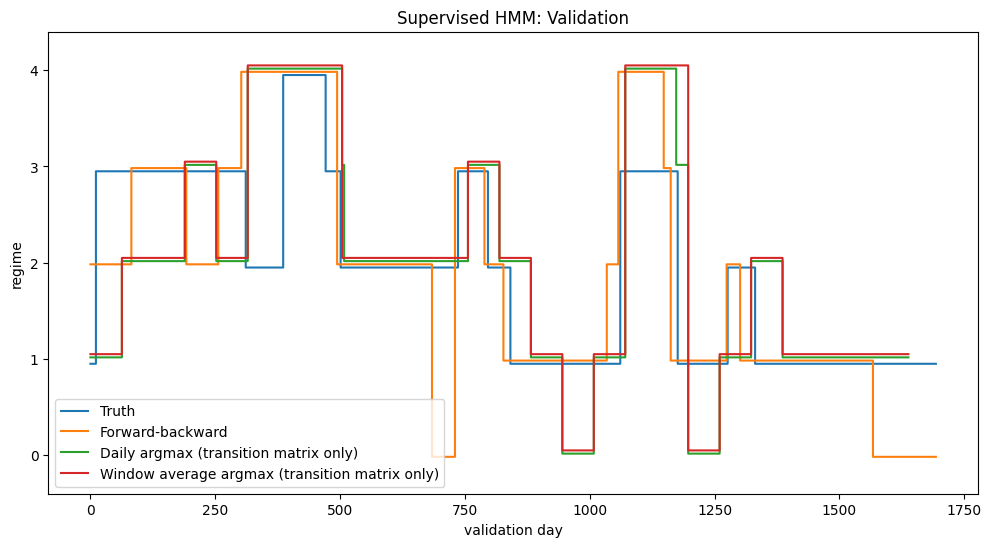

In [5]:
fb_probs, fb_est = models.estimate_states(
    supervised, test_data.emission.values, init_dist, N_REGIMES
)

present = sorted(set(test_regimes.tolist()))
missing = [k for k in range(N_REGIMES) if k not in present]
if missing:
    print(f"Test does not contain regimes {missing}; accuracy uses observed labels.")

fb_acc = models.accuracy_report(test_regimes, fb_est, fb_probs, N_REGIMES, TOP_K)

daily_mask = np.isfinite(walk.daily_argmax)
daily_est = walk.daily_argmax[daily_mask].astype(int)
daily_truth = test_regimes[daily_mask]
daily_score = walk.open_loop_pi[daily_mask]
daily_acc = models.accuracy_report(daily_truth, daily_est, daily_score, N_REGIMES, TOP_K)

window_daily_score = np.full((len(test_regimes), N_REGIMES), np.nan)
for start in walk.hold_starts:
    sl = slice(int(start), int(start) + HORIZON)
    est_states = walk.daily_argmax[sl].astype(int)
    est_avg = np.eye(N_REGIMES)[est_states].mean(axis=0)
    window_daily_score[sl] = est_avg
window_daily_est = walk.window_argmax[daily_mask].astype(int)
window_daily_acc = models.accuracy_report(
    daily_truth, window_daily_est, window_daily_score[daily_mask], N_REGIMES, TOP_K
)

acc_table = pd.DataFrame(
    [
        {
            "estimate": "Forward-backward",
            "truth": "daily clustering labels",
            **fb_acc,
        },
        {
            "estimate": "Daily argmax",
            "truth": "daily clustering labels",
            **daily_acc,
        },
        {
            "estimate": "Window average argmax",
            "truth": "daily clustering labels",
            **window_daily_acc,
        },
    ]
).set_index("estimate")
display(acc_table[["truth", "accuracy"]])

plots.plot_regime_paths(
    {
        "Truth": test_regimes,
        "Forward-backward": fb_est,
        "Daily argmax (transition matrix only)": walk.daily_argmax,
        "Window average argmax (transition matrix only)": walk.window_argmax,
    },
    "Supervised HMM: Test",
    jiggle=0.05,
)


## Scale check


In [6]:
first_hold_date = test_dates.iloc[int(walk.hold_starts[0])]
prior = simple_panel.loc[simple_panel.index < first_hold_date]
lookback_start = prior.index[-LOOKBACK]
real_ref = np.log1p(simple_panel.loc[lookback_start:test_dates.iloc[-1], ASSET_COLS].to_numpy())

scale = run_scale_check(real_ref, specialist_pools, uncond_windows, ASSET_COLS)
display(scale.table)
if not scale.ok:
    for line in scale.messages:
        print(f"[FAIL] {line}")
    raise SystemExit("Scale check failed; synth units do not match real MVO inputs.")
print("[OK] native log-return scale; simple-return std within 0.1×–10× of real")


,source,asset,native_std,simple_mean,simple_std,simple_min,simple_max,simple_p01,simple_p99
0,real,A001,0.0141,0.0004,0.0141,-0.0903,0.1158,-0.0442,0.0406
1,real,A004,0.0024,0.0002,0.0024,-0.0125,0.0133,-0.0063,0.0066
2,real,A006,0.0008,0.0001,0.0008,-0.0062,0.0056,-0.0022,0.0025
3,real,A008,0.0036,0.0003,0.0036,-0.0470,0.0287,-0.0118,0.0099
4,real,A009,0.0044,0.0003,0.0044,-0.0611,0.0486,-0.0115,0.0100
5,real,A011,0.0157,0.0005,0.0156,-0.1002,0.1123,-0.0485,0.0433
6,real,A012,0.0179,0.0005,0.0179,-0.1184,0.0926,-0.0521,0.0531
7,real,A013,0.0135,0.0002,0.0135,-0.0843,0.0859,-0.0411,0.0343
8,real,A014,0.0146,0.0003,0.0145,-0.0948,0.1060,-0.0423,0.0365
9,real,A015,0.0261,0.0005,0.0262,-0.1971,0.1868,-0.0827,0.0884


[OK] native log-return scale; simple-return std within 0.1×–10× of real


## MVO config

Lookback, hold, and step are trading-day counts. Later cells keep these windows and only change objective or constraints. Holds start on 2014-01-06 and stay inside the test slice through 2022-08-31. Mixing is row-append: the training matrix stays 10 columns and grows in rows.


In [7]:
from hmmdiff.mvo.backtest import lookback_and_hold, window_vol_bucket
from hmmdiff.mvo.portfolio_core import TRADING_DAYS, sharpe_ratio

n_assets = len(ASSET_COLS)
mvo_config = pd.DataFrame(
    [
        ("lookback", LOOKBACK, "trading days for μ and Σ"),
        ("hold / horizon", HORIZON, "days the weights are held"),
        ("step", STEP, "days between consecutive hold starts"),
        ("non-overlapping", STEP == HORIZON, "step equals hold"),
        ("mix grid", f"{MIX_GRID[0]}–{MIX_GRID[-1]}%", "synth share of the training matrix"),
        ("n assets", n_assets, ", ".join(ASSET_COLS)),
        ("random state", RANDOM_STATE, "seed + hold_start + n_synth"),
        ("ridge", 1e-6, "covariance diagonal; raised if T ≤ n_feat"),
        ("k*", "window average argmax", "hmm-diffusion specialist pool"),
        ("mix mode", MIX_MODE, "row-append synth under the real lookback"),
        ("default objective", "mean-variance", "later cells override"),
        ("default constraints", "unconstrained", "shorts allowed, no name cap"),
        ("synth window length", int(uncond_windows.shape[1]), "must be ≥ hold"),
        ("uncond pool size", int(uncond_windows.shape[0]), "regime-free CSV"),
        (
            "specialist pool size",
            int(next(iter(specialist_pools.values())).shape[0]),
            "windows per regime",
        ),
        ("train matrix 0%", f"{LOOKBACK} × {n_assets}", "real lookback only"),
        (
            f"train matrix {MIX_GRID[-1]}%",
            f"{LOOKBACK + synth_rows_for_share(LOOKBACK, MIX_GRID[-1] / 100.0)} × {n_assets}",
            "real plus row-appended synth",
        ),
    ],
    columns=["parameter", "value", "note"],
)
display(mvo_config)

hold_rows = []
for i, start in enumerate(walk.hold_starts.tolist()):
    start = int(start)
    sliced = lookback_and_hold(
        simple_panel[ASSET_COLS], test_dates.to_numpy(), start, LOOKBACK, HORIZON
    )
    hold_labels = test_regimes[start : start + HORIZON]
    hold_rows.append(
        {
            "hold": i,
            "start": test_dates.iloc[start].date(),
            "end": test_dates.iloc[start + HORIZON - 1].date(),
            "complete": sliced is not None,
            "bucket": window_vol_bucket(hold_labels),
            "k_star": int(walk.hold_k_star[i]),
        }
    )
holds = pd.DataFrame(hold_rows)
print(
    f"holds scheduled {len(holds)}  complete {int(holds['complete'].sum())}  "
    f"skipped {int((~holds['complete']).sum())}  "
    f"first {holds['start'].iloc[0]}  last start {holds['start'].iloc[-1]}"
)
display(holds["bucket"].value_counts().rename_axis("bucket").to_frame("n_holds"))
display(holds["k_star"].value_counts().sort_index().rename_axis("k*").to_frame("n_holds"))

test_simple = simple_panel.reindex(pd.DatetimeIndex(test_dates))[ASSET_COLS]
ann_mu = test_simple.mean() * TRADING_DAYS
ann_sd = test_simple.std(ddof=0) * np.sqrt(TRADING_DAYS)
asset_stats = pd.DataFrame({"ann_mu": ann_mu, "ann_sd": ann_sd, "sharpe": ann_mu / ann_sd})
pair_corr = test_simple.corr().to_numpy()
mean_pair_corr = float(pair_corr[np.triu_indices_from(pair_corr, k=1)].mean())
ew = test_simple.mean(axis=1).to_numpy()
print(
    f"test panel {test_simple.dropna(how='any').shape[0]} days  "
    f"mean pairwise corr {mean_pair_corr:.3f}  "
    f"equal-weight Sharpe {sharpe_ratio(ew):.3f}"
)
display(asset_stats.T)


,parameter,value,note
0,lookback,252,trading days for μ and Σ
1,hold / horizon,63,days the weights are held
2,step,63,days between consecutive hold starts
3,non-overlapping,True,step equals hold
4,mix grid,0–90%,synth share of the training matrix
5,n assets,10,"A001, A004, A006, A008, A009, A011, A012, A013..."
6,random state,42,seed + hold_start + n_synth
7,ridge,0.0000,covariance diagonal; raised if T ≤ n_feat
8,k*,window average argmax,hmm-diffusion specialist pool
9,mix mode,row,row-append synth under the real lookback


holds scheduled 26  complete 26  skipped 0  first 2007-07-10  last start 2013-07-23


,n_holds
bucket,
low vol,16
high vol,10


,n_holds
k*,
0,2
1,8
2,9
3,2
4,5


validation panel 1694 days  mean pairwise corr 0.292  equal-weight Sharpe 0.460


,A001,A004,A006,A008,A009,A011,A012,A013,A014,A015
ann_mu,0.0758,0.0500,0.0299,0.0848,0.0740,0.0940,0.1034,0.0240,0.0321,0.1177
ann_sd,0.2368,0.0403,0.0137,0.0615,0.0733,0.2624,0.2986,0.2253,0.2413,0.4402
sharpe,0.3202,1.2430,2.1777,1.3786,1.0089,0.3582,0.3463,0.1067,0.1330,0.2675


## MVO backtest

`MIX_GRID` is the synth **share of the whole training matrix**: `synth_rows / (252 + synth_rows)`. 0% is real lookback only. Plots show 0% through 90%.



In [8]:
result = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=True,
    mix_mode=MIX_MODE,
)

n0 = result.windows.loc[result.windows["n_synth"] == 0]
if n0.empty:
    raise SystemExit("No completed MVO holds.")
hmm_n0 = n0.loc[n0["method"] == "hmm-diffusion", ["hold_start", "sharpe", "calmar"]]
mixed_n0 = n0.loc[n0["method"] == "mixed", ["hold_start", "sharpe", "calmar"]]
merged = hmm_n0.merge(mixed_n0, on="hold_start", suffixes=("_hmm", "_mixed"))
sharpe_gap = float(np.nanmax(np.abs(merged["sharpe_hmm"] - merged["sharpe_mixed"])))
calmar_gap = float(np.nanmax(np.abs(merged["calmar_hmm"] - merged["calmar_mixed"])))
print(f"holds scored {merged.shape[0]}  n=0 max |Δ Sharpe| {sharpe_gap:.6g}  |Δ Calmar| {calmar_gap:.6g}")
if sharpe_gap > 1e-10 or calmar_gap > 1e-10:
    raise SystemExit("n=0 hmm-diffusion and mixed should match.")

print("bucket counts at n=0")
display(n0.loc[n0["method"] == "hmm-diffusion", "bucket"].value_counts())
print(f"first hold {result.windows['start_date'].min().date()}  last hold start {result.windows['start_date'].max().date()}")
assert str(result.windows["start_date"].min().date()) == "2014-01-06"


holds scored 26  n=0 max |Δ Sharpe| 0  |Δ Calmar| 0
bucket counts at n=0


bucket
low vol     16
high vol    10
Name: count, dtype: int64

first hold 2007-07-10  last hold start 2013-07-23


## Sharpe and Calmar

The x-axis is **% of synth in the training matrix**: `synth_rows / (real_rows + synth_rows)`. Ticks are 0, 10, 20, …, 90. 0% is all real lookback.


Row-append mix: % of synth is synth_rows / (real_rows + synth_rows). Real lookback stays 252 × 10. 10% adds 28 days; 20% adds 63 days; 90% adds 2268 days.


,synth_pct,real_rows,real_cols,synth_rows,train_rows,train_matrix,synth_row_share
0,0,252,10,0,252,252 × 10,0.0000
1,10,252,10,28,280,280 × 10,0.1000
2,20,252,10,63,315,315 × 10,0.2000
3,30,252,10,108,360,360 × 10,0.3000
4,40,252,10,168,420,420 × 10,0.4000
5,50,252,10,252,504,504 × 10,0.5000
6,60,252,10,378,630,630 × 10,0.6000
7,70,252,10,588,840,840 × 10,0.7000
8,80,252,10,1008,1260,1260 × 10,0.8000
9,90,252,10,2268,2520,2520 × 10,0.9000


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median
0,hmm-diffusion,0,0.0000,high vol,10,-0.2844,0.1140,3.1353,0.4530
20,mixed,0,0.0000,high vol,10,-0.2844,0.1140,3.1353,0.4530
2,hmm-diffusion,10,10.0000,high vol,10,-0.1001,-0.1737,1.8117,-0.8135
22,mixed,10,10.0000,high vol,10,-0.0020,-0.3059,1.7687,-1.7595
4,hmm-diffusion,20,20.0000,high vol,10,-0.0958,0.0090,4.2210,0.4926
24,mixed,20,20.0000,high vol,10,0.2194,-0.1775,2.4185,0.9254
6,hmm-diffusion,30,30.0000,high vol,10,0.1280,0.0445,3.1458,0.1031
26,mixed,30,30.0000,high vol,10,0.4323,-0.3073,1.9660,-0.8585
8,hmm-diffusion,40,40.0000,high vol,10,1.2318,0.5977,7.0673,3.3717
28,mixed,40,40.0000,high vol,10,0.0030,-0.7583,2.2940,-3.5095


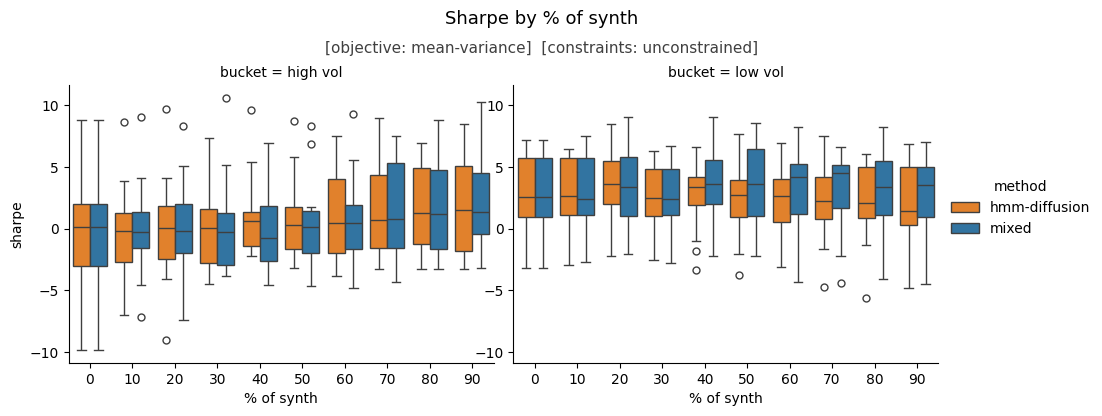

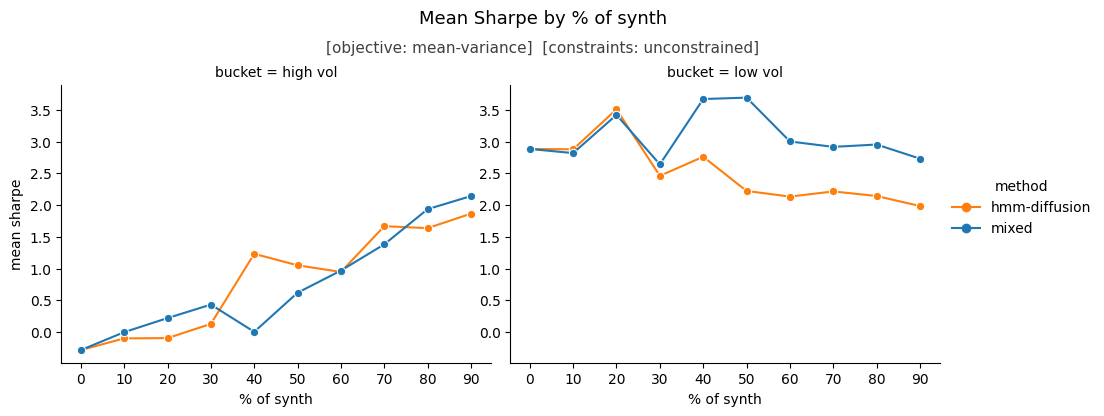

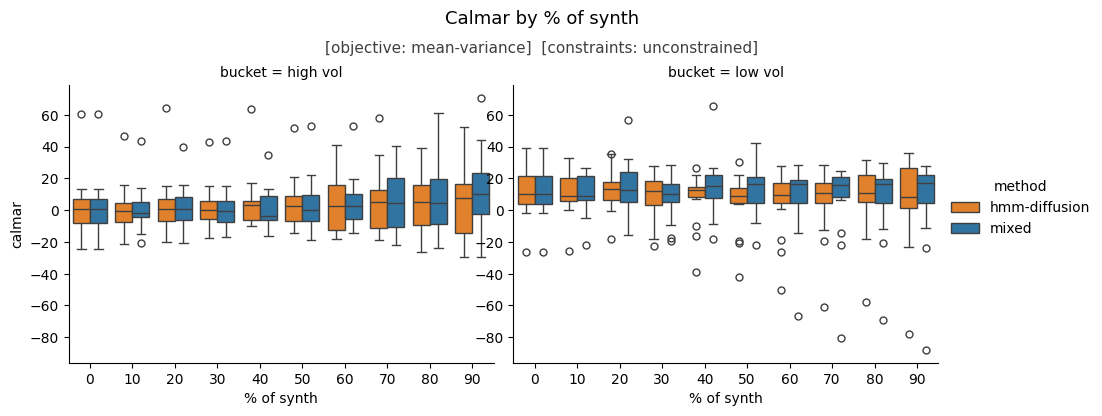

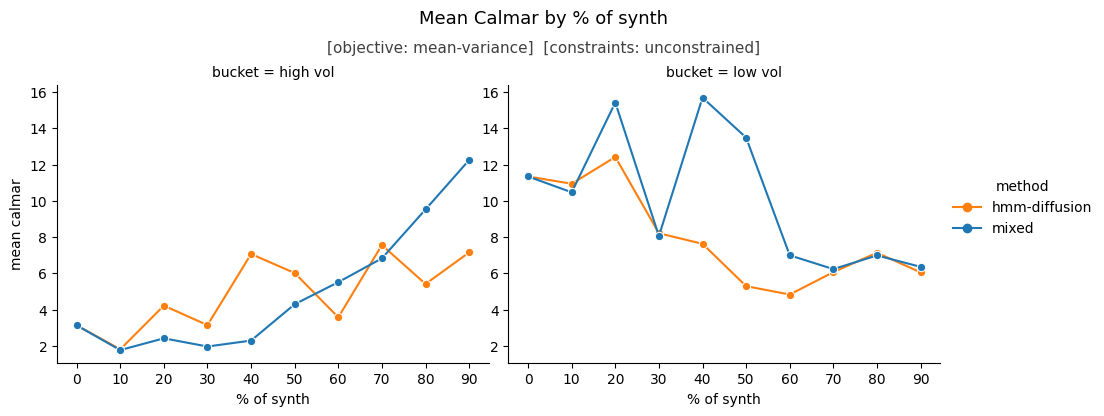

In [9]:
n_assets = len(ASSET_COLS)
synth_rows = [synth_rows_for_share(LOOKBACK, p / 100.0) for p in MIX_GRID]
mix_size = pd.DataFrame(
    {
        "synth_pct": MIX_GRID,
        "real_rows": LOOKBACK,
        "real_cols": n_assets,
        "synth_rows": synth_rows,
        "train_rows": [LOOKBACK + r for r in synth_rows],
        "train_matrix": [f"{LOOKBACK + r} × {n_assets}" for r in synth_rows],
        "synth_row_share": [
            r / (LOOKBACK + r) if r else 0.0 for r in synth_rows
        ],
    }
)
print(
    "Row-append mix: % of synth is synth_rows / (real_rows + synth_rows). "
    "Real lookback stays 252 × 10. 10% adds 28 days; 20% adds 63 days; 90% adds 2268 days."
)
display(mix_size)

display(result.summary.sort_values(["bucket", "n_synth", "method"]))
plots.plot_mvo_boxes(
    result.windows, "sharpe", objective="mean-variance", constraint="unconstrained"
)
plots.plot_mvo_means(
    result.windows, "sharpe", objective="mean-variance", constraint="unconstrained"
)
plots.plot_mvo_boxes(
    result.windows, "calmar", objective="mean-variance", constraint="unconstrained"
)
plots.plot_mvo_means(
    result.windows, "calmar", objective="mean-variance", constraint="unconstrained"
)

## Long-only MVO

Same mix, holds, and seeds as the unconstrained sweep. `allow_short=False` clips negative weights on the 10 assets, then renormalizes. This is clip-and-renorm, not a QP with `w ≥ 0`. `n=0` long-only will not match unconstrained `n=0`.


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median
0,hmm-diffusion,0,0.0000,high vol,10,0.8754,0.3404,4.0307,0.4949
20,mixed,0,0.0000,high vol,10,0.8754,0.3404,4.0307,0.4949
2,hmm-diffusion,10,10.0000,high vol,10,1.0260,0.6896,4.3507,1.0684
22,mixed,10,10.0000,high vol,10,1.2358,0.7146,5.9637,0.8910
4,hmm-diffusion,20,20.0000,high vol,10,1.2690,0.6124,6.1550,0.8709
24,mixed,20,20.0000,high vol,10,1.2991,1.0283,4.5021,1.4027
6,hmm-diffusion,30,30.0000,high vol,10,1.1249,0.3052,4.9714,0.5538
26,mixed,30,30.0000,high vol,10,1.4117,0.6557,5.5913,0.8538
8,hmm-diffusion,40,40.0000,high vol,10,1.6908,0.7957,7.1269,1.1506
28,mixed,40,40.0000,high vol,10,1.2515,0.9059,4.9865,1.5152


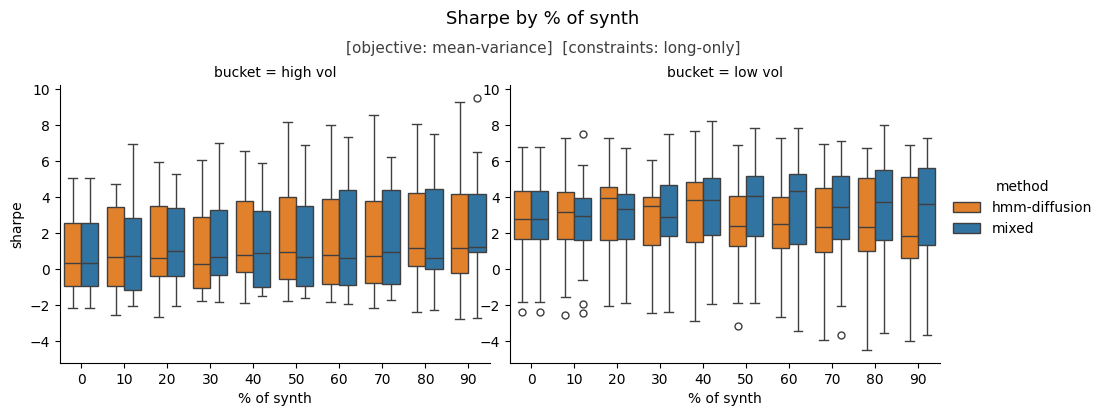

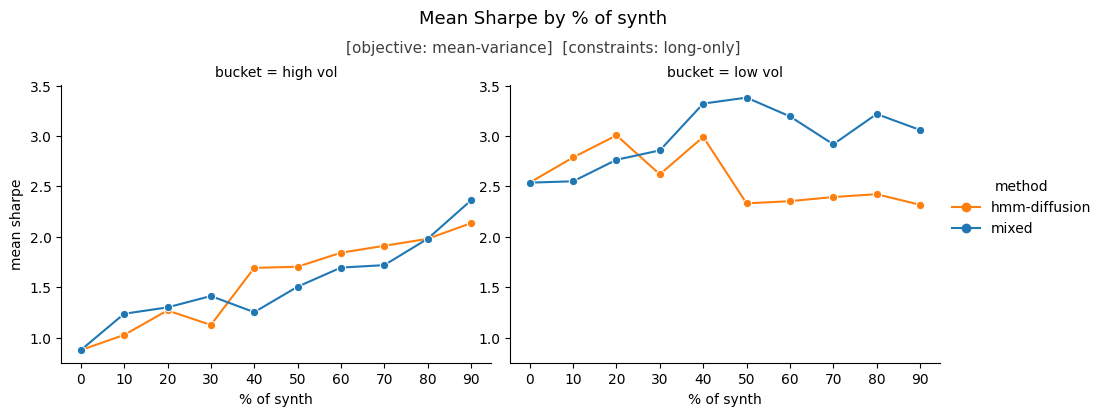

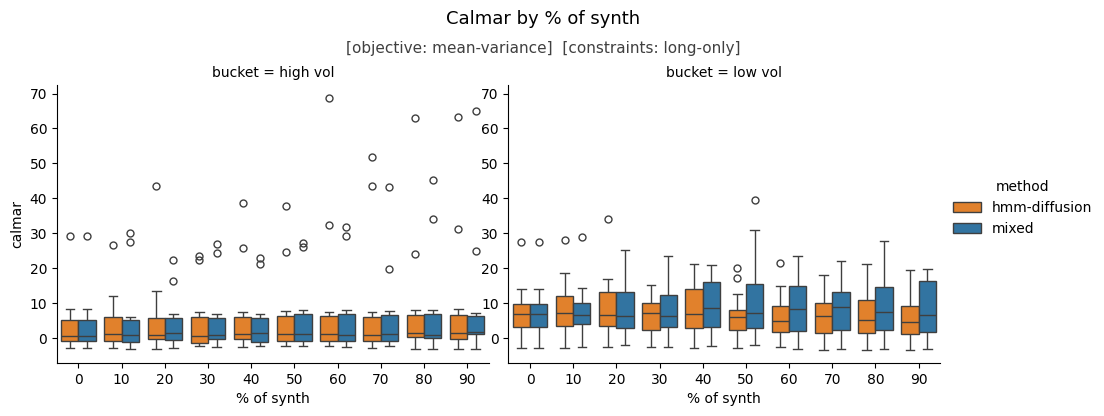

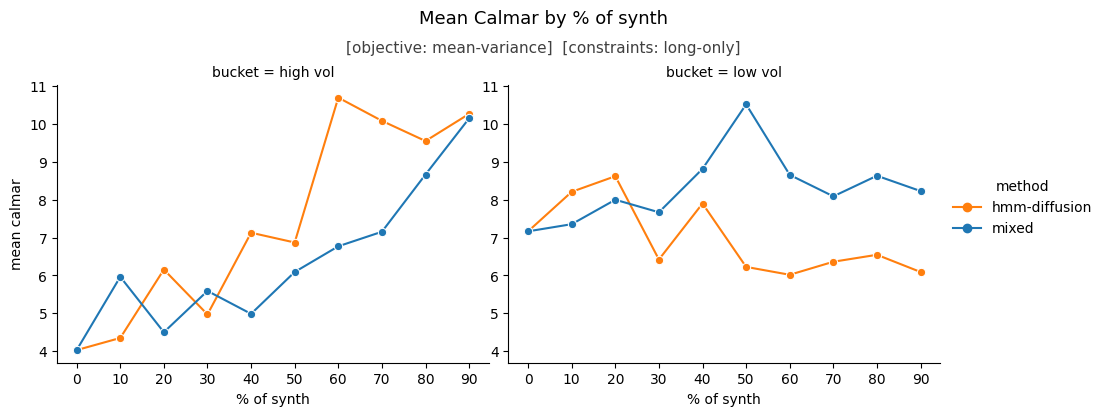

In [10]:
result_long_only = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    mix_mode=MIX_MODE,
)

display(result_long_only.summary.sort_values(["bucket", "n_synth", "method"]))
plots.plot_mvo_boxes(
    result_long_only.windows, "sharpe", objective="mean-variance", constraint="long-only"
)
plots.plot_mvo_means(
    result_long_only.windows, "sharpe", objective="mean-variance", constraint="long-only"
)
plots.plot_mvo_boxes(
    result_long_only.windows, "calmar", objective="mean-variance", constraint="long-only"
)
plots.plot_mvo_means(
    result_long_only.windows, "calmar", objective="mean-variance", constraint="long-only"
)


## Long-only 30% cap

Same mix, holds, and seeds. After Markowitz, the 10 traded weights are projected onto `sum w = 1`, `w ≥ 0`, and `w ≤ 0.30`. That is a standard name cap: no asset can be more than 30% of the book.


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median
0,hmm-diffusion,0,0.0000,high vol,10,0.6749,0.5293,3.3070,0.7077
20,mixed,0,0.0000,high vol,10,0.6749,0.5293,3.3070,0.7077
2,hmm-diffusion,10,10.0000,high vol,10,0.6690,0.4386,3.2570,0.6283
22,mixed,10,10.0000,high vol,10,0.8498,0.7679,3.8667,1.0264
4,hmm-diffusion,20,20.0000,high vol,10,0.7116,0.6847,3.4912,1.0091
24,mixed,20,20.0000,high vol,10,0.9626,0.9575,3.4595,1.4587
6,hmm-diffusion,30,30.0000,high vol,10,0.7395,0.3033,3.0617,0.6654
26,mixed,30,30.0000,high vol,10,1.1733,0.7469,4.4659,1.0335
8,hmm-diffusion,40,40.0000,high vol,10,1.2667,0.7399,5.0842,1.1475
28,mixed,40,40.0000,high vol,10,0.8243,0.5430,3.3687,0.9544


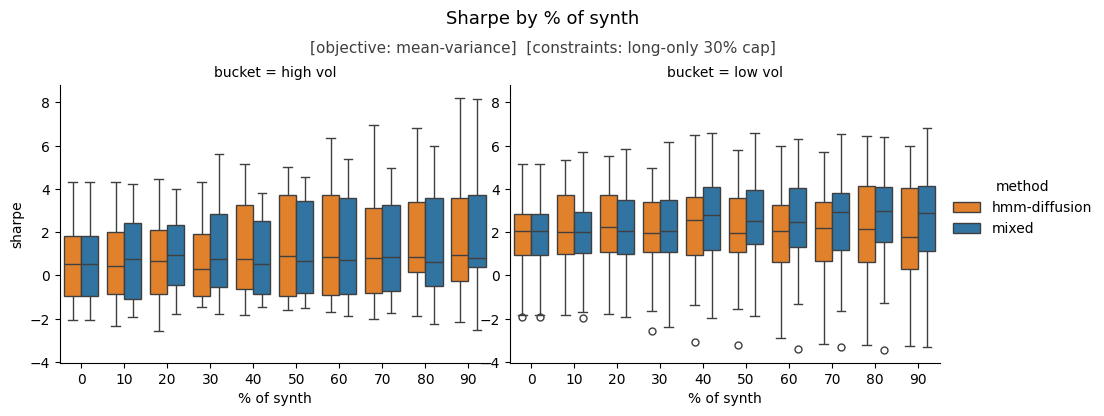

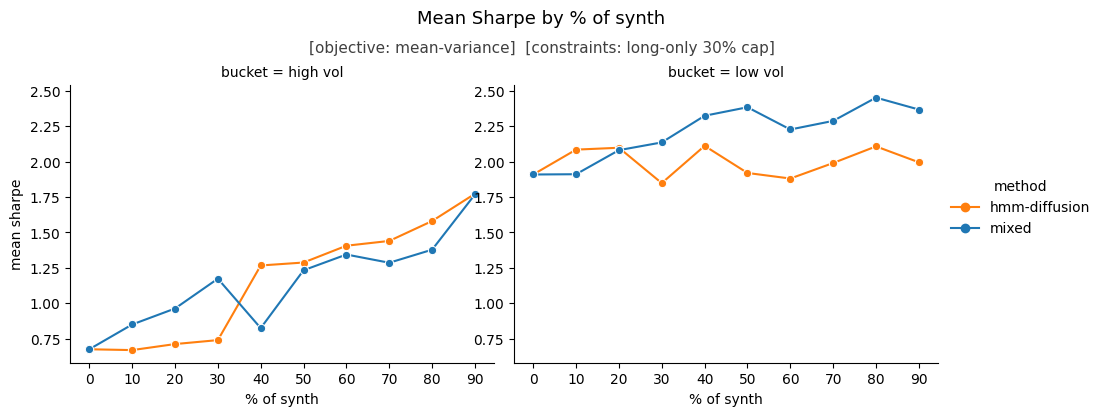

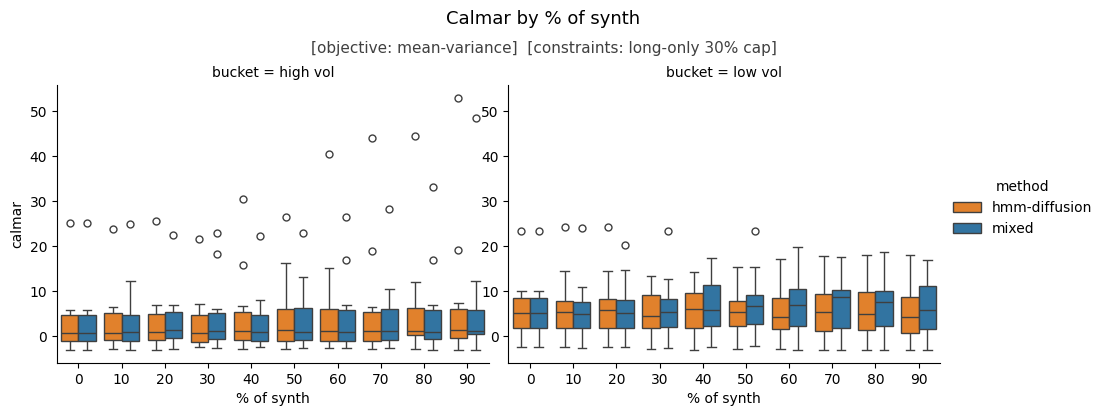

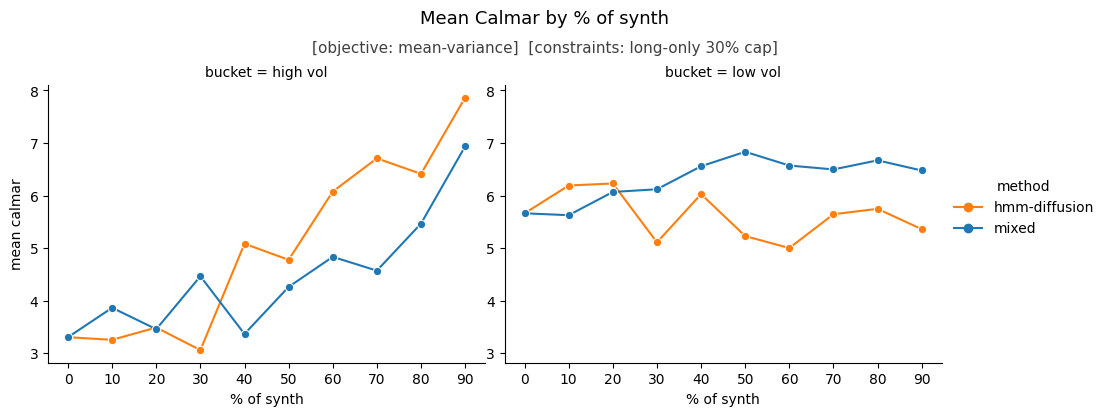

In [11]:
MAX_WEIGHT = 0.30
result_capped = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
    mix_mode=MIX_MODE,
)

display(result_capped.summary.sort_values(["bucket", "n_synth", "method"]))
plots.plot_mvo_boxes(
    result_capped.windows,
    "sharpe",
    objective="mean-variance",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_capped.windows,
    "sharpe",
    objective="mean-variance",
    constraint="long-only 30% cap",
)
plots.plot_mvo_boxes(
    result_capped.windows,
    "calmar",
    objective="mean-variance",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_capped.windows,
    "calmar",
    objective="mean-variance",
    constraint="long-only 30% cap",
)


## Long-only 30% cap, max Sharpe

Same mix, holds, seeds, long-only, and 30% name cap as the previous cell. Weights maximize Sharpe (`w ∝ Σ^{-1} μ`, rf = 0) on the row-appended 10-asset matrix, then project onto `w ≥ 0`, `w ≤ 0.30`, `sum w = 1`.


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median
0,hmm-diffusion,0,0.0000,high vol,10,1.0253,0.7365,4.0407,1.1209
20,mixed,0,0.0000,high vol,10,1.0253,0.7365,4.0407,1.1209
2,hmm-diffusion,10,10.0000,high vol,10,1.1510,0.8567,4.2646,1.2729
22,mixed,10,10.0000,high vol,10,1.2952,0.7961,5.3881,1.2693
4,hmm-diffusion,20,20.0000,high vol,10,1.3992,0.7735,5.4261,1.2459
24,mixed,20,20.0000,high vol,10,1.3523,0.8401,4.6376,1.2558
6,hmm-diffusion,30,30.0000,high vol,10,1.4044,0.7036,5.0928,1.0584
26,mixed,30,30.0000,high vol,10,1.4686,0.7453,5.9255,1.0603
8,hmm-diffusion,40,40.0000,high vol,10,1.8814,0.9965,7.7571,1.3070
28,mixed,40,40.0000,high vol,10,1.3473,0.7970,4.8614,1.1760


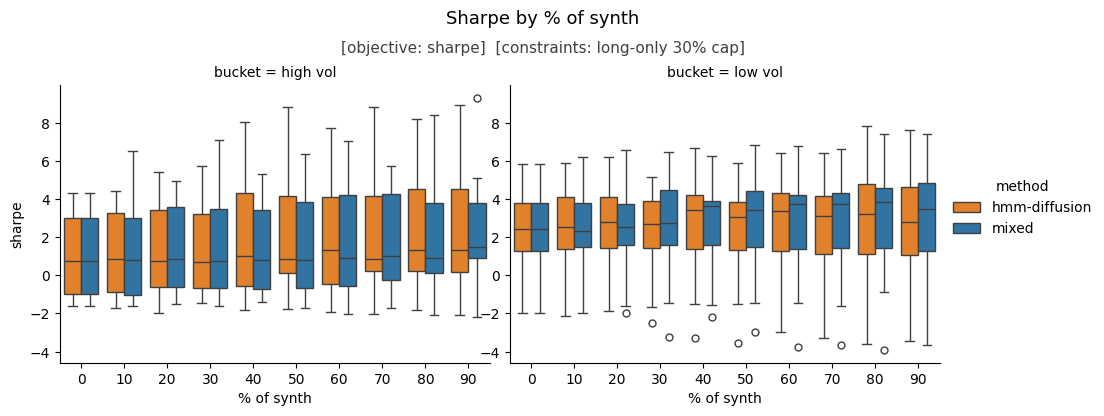

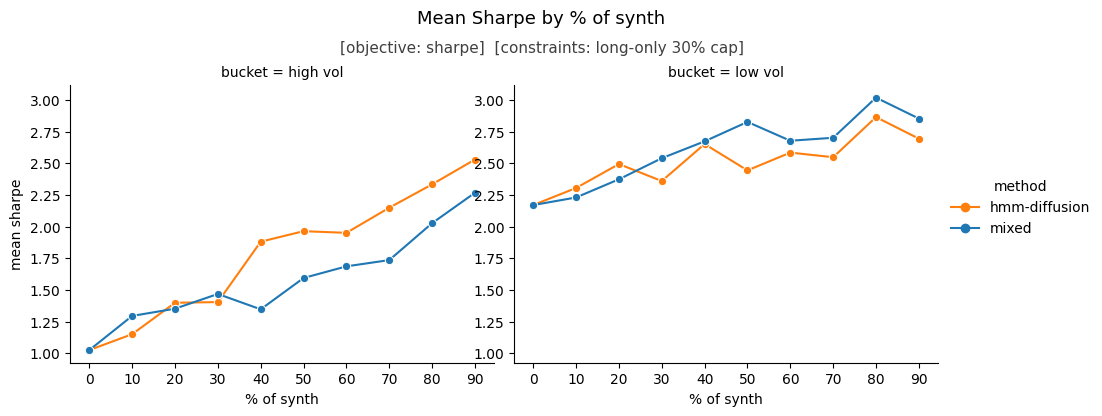

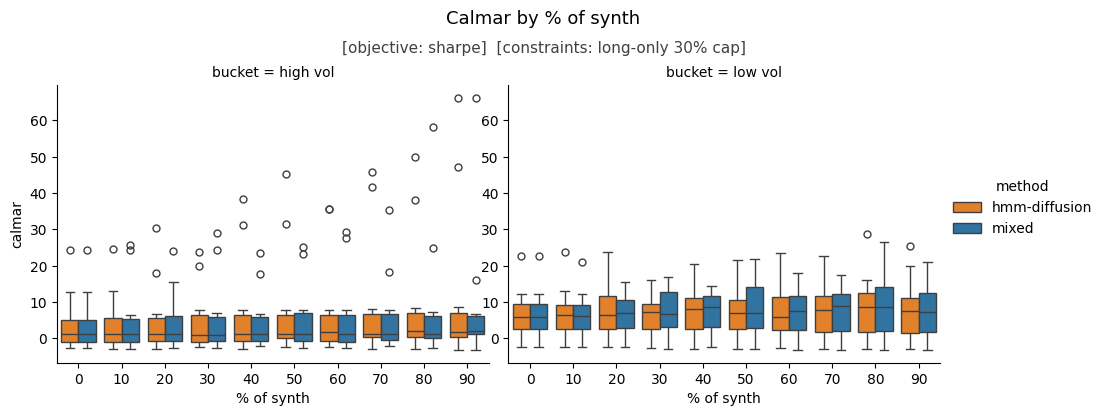

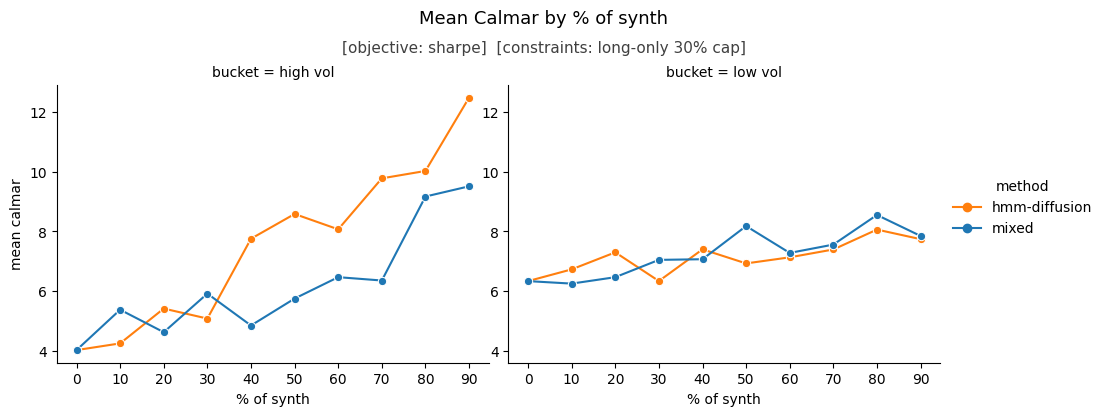

In [12]:
MAX_WEIGHT = 0.30
result_max_sharpe = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
    objective="max_sharpe",
    mix_mode=MIX_MODE,
)

display(result_max_sharpe.summary.sort_values(["bucket", "n_synth", "method"]))
plots.plot_mvo_boxes(
    result_max_sharpe.windows,
    "sharpe",
    objective="sharpe",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_max_sharpe.windows,
    "sharpe",
    objective="sharpe",
    constraint="long-only 30% cap",
)
plots.plot_mvo_boxes(
    result_max_sharpe.windows,
    "calmar",
    objective="sharpe",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_max_sharpe.windows,
    "calmar",
    objective="sharpe",
    constraint="long-only 30% cap",
)


## Long-only 30% cap, min variance

Same mix, holds, seeds, long-only, and 30% name cap. Weights are global minimum variance (`w ∝ Σ^{-1} 1`) on the row-appended 10-asset matrix, then project onto the 30% cap.


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median
0,hmm-diffusion,0,0.0000,high vol,10,0.7082,0.7231,3.0440,1.1961
20,mixed,0,0.0000,high vol,10,0.7082,0.7231,3.0440,1.1961
2,hmm-diffusion,10,10.0000,high vol,10,0.7446,0.7380,3.1226,1.2045
22,mixed,10,10.0000,high vol,10,0.7523,0.7268,3.0967,1.1648
4,hmm-diffusion,20,20.0000,high vol,10,0.7734,0.6625,3.1721,1.0962
24,mixed,20,20.0000,high vol,10,0.7420,0.7005,3.0874,1.1667
6,hmm-diffusion,30,30.0000,high vol,10,0.7918,0.7281,3.2038,1.1696
26,mixed,30,30.0000,high vol,10,0.8073,0.7322,3.2621,1.1573
8,hmm-diffusion,40,40.0000,high vol,10,0.7736,0.7291,3.2140,1.1801
28,mixed,40,40.0000,high vol,10,0.8505,0.7820,3.4023,1.2382


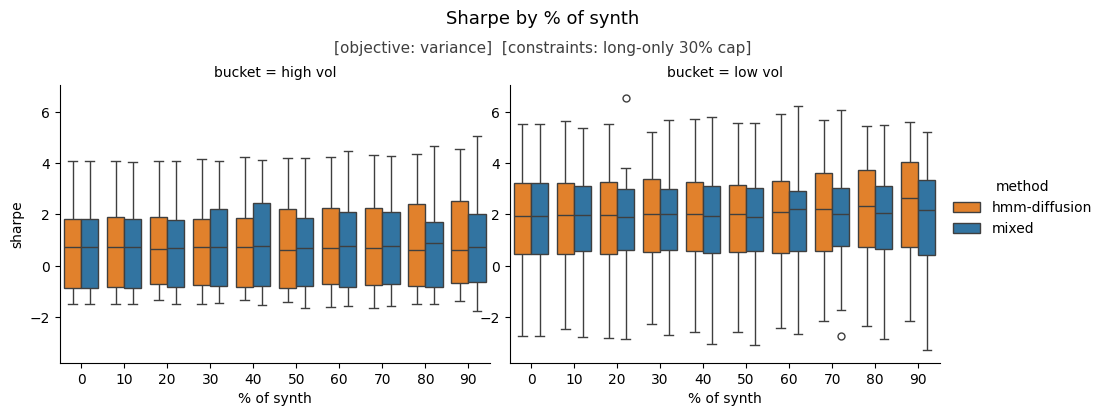

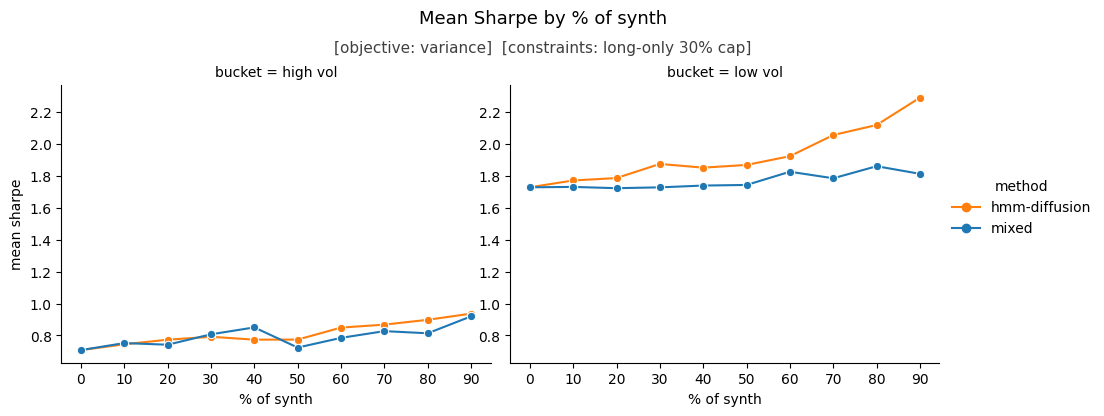

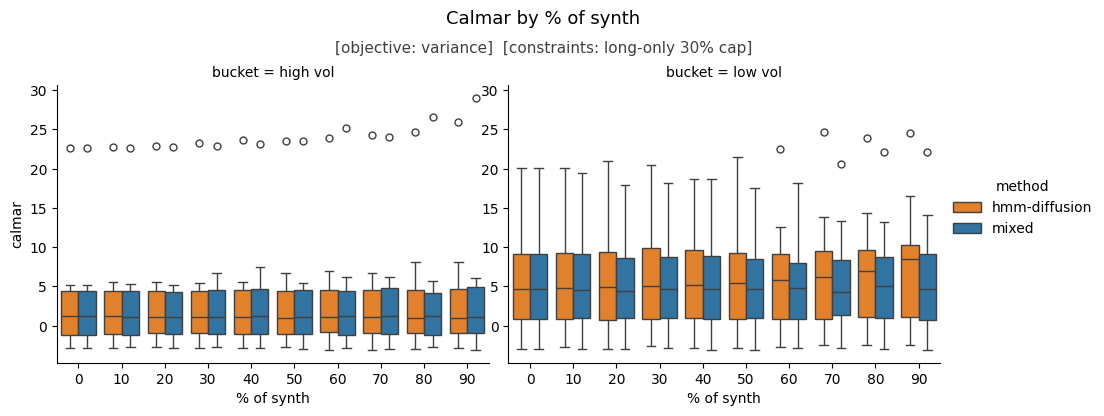

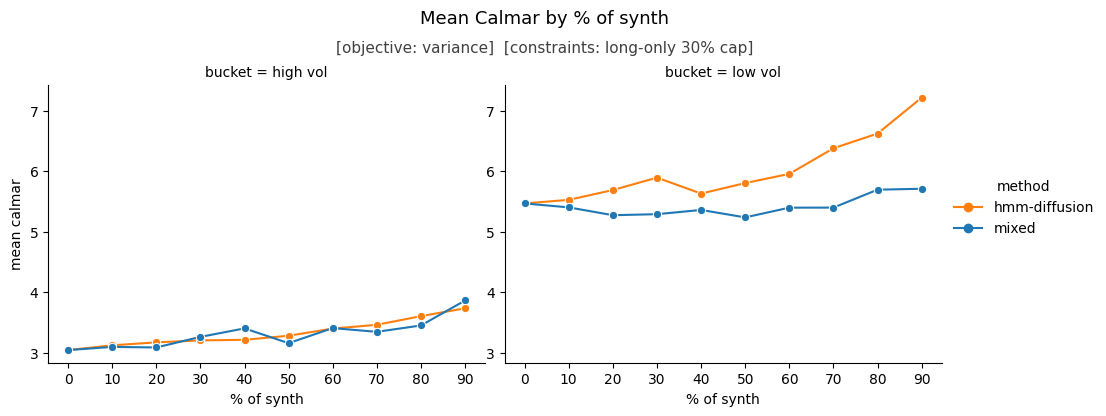

In [13]:
result_min_var = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
    objective="min_variance",
    mix_mode=MIX_MODE,
)

display(result_min_var.summary.sort_values(["bucket", "n_synth", "method"]))
plots.plot_mvo_boxes(
    result_min_var.windows,
    "sharpe",
    objective="variance",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_min_var.windows,
    "sharpe",
    objective="variance",
    constraint="long-only 30% cap",
)
plots.plot_mvo_boxes(
    result_min_var.windows,
    "calmar",
    objective="variance",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_min_var.windows,
    "calmar",
    objective="variance",
    constraint="long-only 30% cap",
)


## Long-only 30% cap, max return

Same mix, holds, seeds, long-only, and 30% name cap. Fill the highest-mean names first: 30% in the best, 30% in the next, and so on, until the weights sum to 1. Means come from the row-appended 10-asset matrix. Covariance is not used.


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median
0,hmm-diffusion,0,0.0000,high vol,10,0.7884,-0.0193,4.2067,0.1775
20,mixed,0,0.0000,high vol,10,0.7884,-0.0193,4.2067,0.1775
2,hmm-diffusion,10,10.0000,high vol,10,0.7575,0.1003,4.0822,0.2993
22,mixed,10,10.0000,high vol,10,0.7687,0.4453,4.2408,0.8434
4,hmm-diffusion,20,20.0000,high vol,10,0.8545,0.6029,4.2711,0.9859
24,mixed,20,20.0000,high vol,10,0.8893,0.5608,4.3594,0.9569
6,hmm-diffusion,30,30.0000,high vol,10,0.6033,0.2229,4.1527,0.4874
26,mixed,30,30.0000,high vol,10,0.3600,0.6200,2.0037,1.1148
8,hmm-diffusion,40,40.0000,high vol,10,0.1498,0.3789,1.5122,0.8074
28,mixed,40,40.0000,high vol,10,0.2869,0.4650,1.8275,0.9248


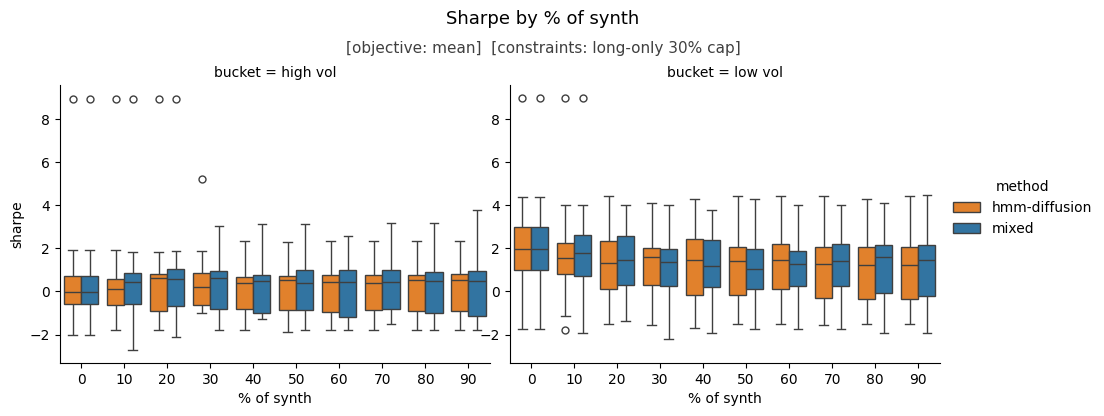

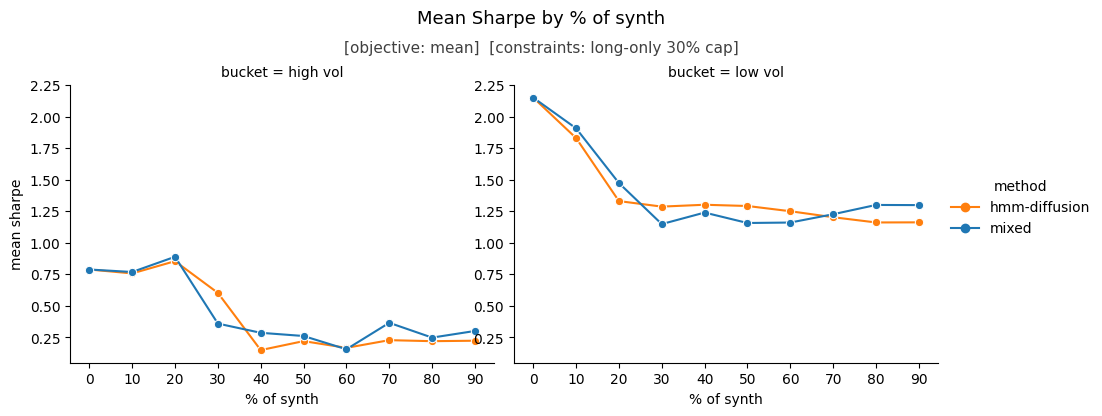

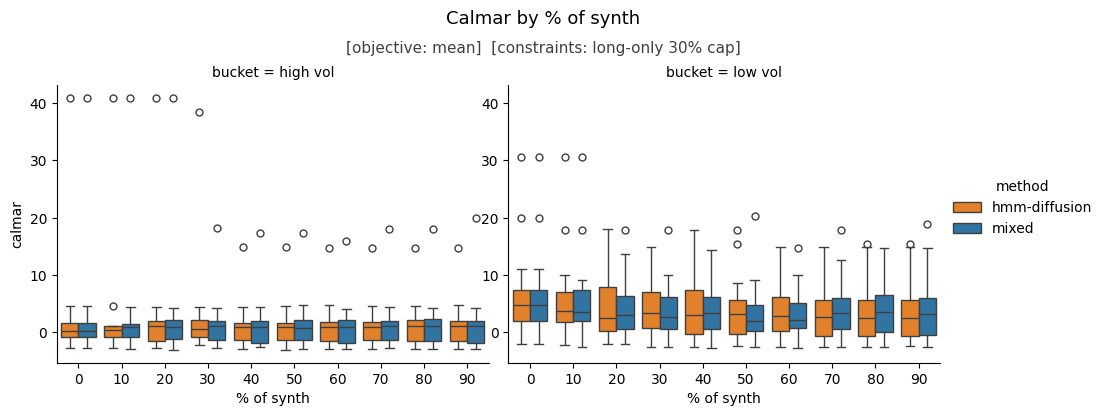

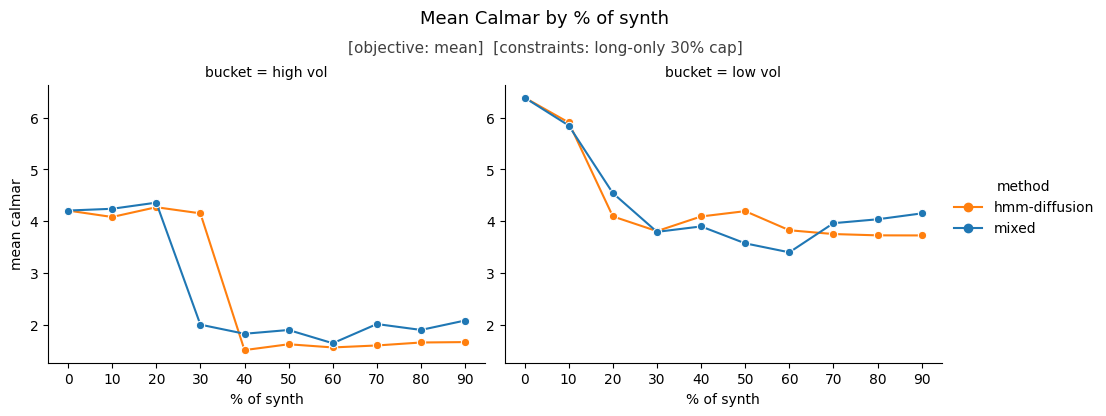

In [14]:
result_max_return = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
    objective="max_return",
    mix_mode=MIX_MODE,
)

display(result_max_return.summary.sort_values(["bucket", "n_synth", "method"]))
plots.plot_mvo_boxes(
    result_max_return.windows,
    "sharpe",
    objective="mean",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_max_return.windows,
    "sharpe",
    objective="mean",
    constraint="long-only 30% cap",
)
plots.plot_mvo_boxes(
    result_max_return.windows,
    "calmar",
    objective="mean",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_max_return.windows,
    "calmar",
    objective="mean",
    constraint="long-only 30% cap",
)
